# Optimización de Hiperparámetros y Validación Cruzada

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AxelSkrauba/applied-ai-engineering/blob/main/notebooks/03_machine_learning/07_optimizacion_hiperparametros_y_cv.ipynb)

## Objetivos


- Diferenciar conceptualmente entre los **Parámetros** (aprendidos por el modelo) y los **Hiperparámetros** (configurados por el ingeniero).
- Comprender e implementar la **Validación Cruzada (K-Fold Cross-Validation)** para evaluar modelos sin sesgar los resultados.
- Sistematizar la búsqueda de la configuración óptima comparando la fuerza bruta (`GridSearchCV`) frente al muestreo estocástico (`RandomizedSearchCV`), analizando sus costos computacionales.



## Prerrequisitos


- Entendimiento del *Trade-off* Sesgo-Varianza y el peligro del *Overfitting*.
- Haber completado: [Clasificación: Árboles de Decisión y Reglas Lógicas](04_clasificacion_arboles_y_reglas.ipynb).

---



## Configuración del Entorno


In [ ]:
# @title *Esta celda clona el repositorio (en Colab) e importa las utilidades comunes*
import sys
import os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    import subprocess
    REPO_NAME = "applied-ai-engineering"
    if not os.path.exists(REPO_NAME):
        subprocess.run(["git", "clone", f"https://github.com/AxelSkrauba/{REPO_NAME}.git"], check=True)
    os.chdir(f"/content/{REPO_NAME}")
    sys.path.append(f"/content/{REPO_NAME}")
else:
    # Repositorio en local, apuntar path a la raiz
    os.chdir(f"../../")

from utils.plots import setup_plot_style
from utils.data import load_dataset
setup_plot_style()

## Introducción Teórica



Hasta ahora, hemos instanciado nuestros modelos usando los valores por defecto de Scikit-Learn o adivinando algunos números (ej. `max_depth=3` o `C=100`). A estos "diales" o "perillas" de configuración se les llama **Hiperparámetros**.

- **Parámetros:** Son los valores que el algoritmo aprende por sí solo durante el entrenamiento (ej. los pesos $w$ en una regresión lineal, o las reglas de corte en un nodo de un árbol).
- **Hiperparámetros:** Son las reglas del juego que el ingeniero define *antes* de que comience el entrenamiento (ej. la profundidad máxima permitida para el árbol, o el tipo de Kernel en un SVM).

El proceso de encontrar la combinación perfecta de estos diales se conoce como *Hyperparameter Tuning*.



### El Peligro del *Data Snooping* y la Validación Cruzada



Supongamos que se prueban 50 combinaciones de hiperparámetros y  se evalúa cada una usando el conjunto de prueba (*Test Set*). Después, se elige la combinación que dio el `99%` de *Accuracy*. ¡Felicidades! Acabas de cometer **Data Snooping** (Fuga de Información).

Al usar el *Test Set* repetidamente para tomar decisiones sobre el modelo, ese conjunto de datos ha perdido su pureza. El modelo se ha sobreajustado indirectamente a los datos de prueba. Cuando lo lleves a producción, su rendimiento real será mucho menor.

**La solución de ingeniería es la Validación Cruzada (K-Fold CV):**
1. Apartamos el *Test Set* y lo encerramos en una "caja fuerte". No lo tocamos hasta el final del proyecto.
2. Tomamos el *Train Set* y lo dividimos en $K$ partes iguales (ej. $K=5$ *folds*).
3. Entrenamos el modelo en 4 partes y lo validamos en la 5ta. Repetimos esto 5 veces, rotando la parte de validación.
4. El rendimiento del modelo es el promedio de las 5 validaciones.

Ver esquema a continuación:

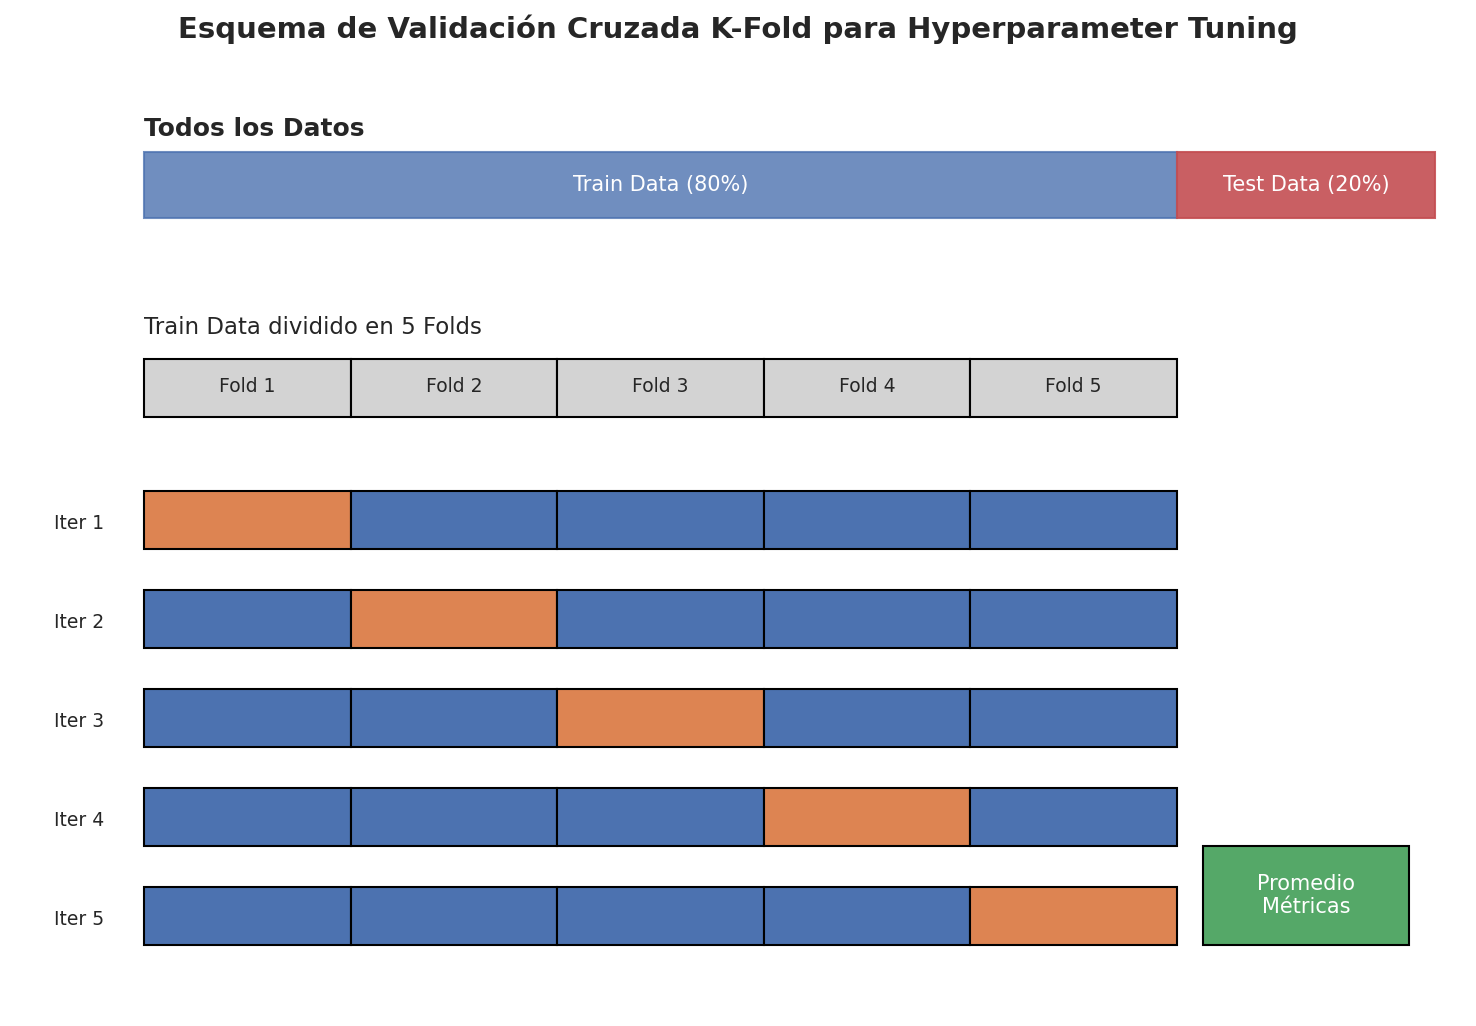

In [10]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import warnings
warnings.filterwarnings("ignore")

# -----------------------------
# Configuración general
# -----------------------------
K = 5
train_color = "#4C72B0"   # azul entrenamiento
val_color = "#DD8452"     # naranja validación
test_color = "#C44E52"    # rojo test

fig, ax = plt.subplots(figsize=(10,7))

# -----------------------------
# Barra superior: Todos los datos
# -----------------------------
ax.text(0, 6.3, "Todos los Datos", fontsize=12, weight='bold')

# Train
ax.add_patch(Rectangle((0,5.8), 8, 0.4, color=train_color, alpha=0.8))
ax.text(4,6.0,"Train Data (80%)", ha="center", va="center", color="white", fontsize=10)

# Test (con candado)
ax.add_patch(Rectangle((8,5.8), 2, 0.4, color=test_color, alpha=0.9))
ax.text(9,6.0,"Test Data (20%)", ha="center", va="center", color="white", fontsize=10)

# -----------------------------
# Folds del train
# -----------------------------
ax.text(0,5.1,"Train Data dividido en 5 Folds", fontsize=11)

fold_width = 1.6
for i in range(K):
    ax.add_patch(Rectangle((i*fold_width,4.6), fold_width,0.35,
                           edgecolor="black", facecolor="lightgray"))
    ax.text(i*fold_width + fold_width/2,4.78,f"Fold {i+1}",
            ha="center",va="center",fontsize=9)

# -----------------------------
# Iteraciones K-Fold
# -----------------------------
y_start = 3.8
gap = 0.6

for k in range(K):

    y = y_start - k*gap
    ax.text(-0.7,y+0.12,f"Iter {k+1}",fontsize=9)

    for i in range(K):

        color = val_color if i==k else train_color

        ax.add_patch(Rectangle(
            (i*fold_width,y),
            fold_width,
            0.35,
            edgecolor="black",
            facecolor=color
        ))

# -----------------------------
# Bloque final: promedio métricas
# -----------------------------
ax.add_patch(Rectangle((8.2,1.4),1.6,0.6,
                       facecolor="#55A868",
                       edgecolor="black"))

ax.text(9,1.7,"Promedio\nMétricas",
        ha="center",va="center",color="white",fontsize=10)


# -----------------------------
# Formato final
# -----------------------------
ax.set_xlim(-1,10.2)
ax.set_ylim(1,6.7)

ax.set_title(
    "Esquema de Validación Cruzada K-Fold para Hyperparameter Tuning",
    fontsize=14,
    pad=15
)

ax.axis("off")
plt.tight_layout()
plt.show()

## Desarrollo e Implementación



Vamos a trabajar con el **Air Quality Dataset (ADL)**. Nuestro objetivo es clasificar qué actividad se está realizando en una habitación (4 clases posibles) basándonos en las lecturas de 6 sensores de gas.

Utilizamos un **Árbol de Decisión**. *¿Por qué un árbol?* Porque los árboles no requieren que los datos estén escalados. Esto es crucial para este notebook, y explicamos el porqué al final.



In [ ]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# 1. Carga de datos
dataset_path = "datasets/adl/datos_adl.csv"
df = load_dataset(dataset_path)

X = df.drop(columns=['Situacion'])
y = df['Situacion']

# 2. Separamos el Test Set (La "Caja Fuerte")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Tamaño del set de entrenamiento para CV: {X_train.shape[0]} muestras")

Archivo CSV no encontrado. Descomprimiendo /content/applied-ai-engineering/datasets/adl/datos_adl.zip...
Descompresión completa. Intentando cargar el CSV.
Dataset cargado exitosamente con 1845 filas y 7 columnas.
Tamaño del set de entrenamiento para CV: 1476 muestras


### Estrategia 1: Grid Search (Fuerza Bruta)



`GridSearchCV` toma un diccionario de hiperparámetros, genera **todas las combinaciones posibles**, y evalúa cada una usando Validación Cruzada.

Vamos a definir un espacio de búsqueda amplio para nuestro árbol:



In [ ]:
# Definimos el espacio de búsqueda (La "Cuadrícula" o Grid)
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'max_features': [None, 'sqrt', 'log2']
}

# ¿Cuántos modelos vamos a entrenar?
# 2 * 5 * 4 * 4 * 3 = 480 combinaciones.
# Con 5-Fold CV, entrenaremos 480 * 5 = 2.400 árboles de decisión.

# Instanciamos el modelo base
arbol_base = DecisionTreeClassifier(random_state=42)

# Configuramos el Grid Search
grid_search = GridSearchCV(
    estimator=arbol_base,
    param_grid=param_grid,
    cv=5,                  # 5-Fold Cross Validation
    scoring='accuracy',    # Métrica a optimizar
    n_jobs=-1,             # Usar todos los núcleos del procesador
    verbose=1              # Mostrar progreso
)

# Ejecutamos la búsqueda y medimos el tiempo
start_time = time.time()
grid_search.fit(X_train, y_train)
grid_time = time.time() - start_time

print(f"\n--- Resultados de Grid Search ---")
print(f"Tiempo de ejecución: {grid_time:.2f} segundos")
print(f"Mejor combinación de hiperparámetros:\n{grid_search.best_params_}")
print(f"Mejor Accuracy en CV: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 480 candidates, totalling 2400 fits

--- Resultados de Grid Search ---
Tiempo de ejecución: 19.87 segundos
Mejor combinación de hiperparámetros:
{'criterion': 'entropy', 'max_depth': None, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Mejor Accuracy en CV: 0.9302


### Estrategia 2: Random Search (Muestreo Estocástico)



Si tuviéramos un modelo más pesado (como un SVM) o un dataset de 1 millón de filas, entrenar 2.400 modelos tomaría días.

`RandomizedSearchCV` no prueba todas las combinaciones. En su lugar, elige aleatoriamente un número fijo de combinaciones (ej. 50). Matemáticamente, se ha demostrado que si la configuración óptima ocupa al menos el 5% del espacio de búsqueda, Random Search con 60 iteraciones tiene un 95% de probabilidad de encontrarla, en una fracción del tiempo.



In [ ]:
# Configuramos el Random Search usando el MISMO espacio de búsqueda
random_search = RandomizedSearchCV(
    estimator=arbol_base,
    param_distributions=param_grid,
    n_iter=50,             # ¡Solo probamos 50 combinaciones al azar!
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# Ejecutamos la búsqueda y medimos el tiempo
start_time = time.time()
random_search.fit(X_train, y_train)
random_time = time.time() - start_time

print(f"\n--- Resultados de Random Search ---")
print(f"Tiempo de ejecución: {random_time:.2f} segundos")
print(f"Mejor combinación de hiperparámetros:\n{random_search.best_params_}")
print(f"Mejor Accuracy en CV: {random_search.best_score_:.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits

--- Resultados de Random Search ---
Tiempo de ejecución: 1.70 segundos
Mejor combinación de hiperparámetros:
{'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 20, 'criterion': 'entropy'}
Mejor Accuracy en CV: 0.9275


## Resultados y Discusión



Comparamos los resultados de ambas estrategias:

1. **Tiempos de Cómputo:** Random Search fue drásticamente más rápido (tomó un 10% del tiempo que Grid Search, ya que solo evaluó 50 combinaciones frente a 480).
2. **Rendimiento (Accuracy):** Normalmente, es muy probable que el *Accuracy* obtenido por Random Search sea idéntico o marginalmente inferior (por décimas porcentuales) al de Grid Search. Arriba, la diferencia es de solamente `0,0027`.

**Criterio de Ingeniería:**
En la industria, el tiempo de cómputo cuesta dinero (servidores en la nube). La regla general es:
- Usar **Grid Search** solo cuando se tenga un espacio de búsqueda muy pequeño (menos de 50 combinaciones) o un modelo extremadamente rápido de entrenar.
- Usar **Random Search** (o técnicas más avanzadas como Optimización Bayesiana con librerías como *Optuna*) como el estándar por defecto para la mayoría de los proyectos reales.

Notar que, el espacio de búsqueda... lo configuramos nosotros. Si se hace mal esto... ¿podemos esperar un buen resultado?

### La Prueba Final (Abriendo la Caja Fuerte)



Ahora que hemos encontrado el mejor modelo usando Validación Cruzada, es hora de evaluarlo con los datos que nunca ha visto.



In [ ]:
# Extraemos el mejor modelo encontrado por Random Search
mejor_modelo = random_search.best_estimator_

# Lo evaluamos en el Test Set
y_pred_test = mejor_modelo.predict(X_test)
acc_final = accuracy_score(y_test, y_pred_test)

print(f"Accuracy Final en el Test Set (Datos no vistos): {acc_final:.4f}")

Accuracy Final en el Test Set (Datos no vistos): 0.9268



Si el *Accuracy* del Test Set es muy similar al *Accuracy* de la Validación Cruzada, ¡felicidades! Has construido un modelo robusto que generaliza bien.

En este caso, obtuvimos un resultado excelente.

---



## ⚠️ El Peligro Oculto del Preprocesamiento



En este notebook, optimizamos un modelo "puro". Elegimos un Árbol de Decisión a propósito porque **no requiere escalar los datos ni imputar valores nulos**.

Pero, ¿qué pasaría si hubiéramos usado un SVM o un KNN? Habríamos tenido que usar un `StandardScaler`.

**El error de novato más común en Machine Learning es este:**


```python
# MALA PRÁCTICA (DATA LEAKAGE)
X_train_scaled = scaler.fit_transform(X_train)
grid_search.fit(X_train_scaled, y_train)
```

Si se escala *todo* el `X_train` antes de pasarlo al `GridSearchCV`, la media y la desviación estándar utilizadas para escalar contendrán información de los 5 *folds*. Cuando el algoritmo separe el *fold* de validación, **ese fold ya estará contaminado con información del resto del dataset**. Por lo tanto, la Validación Cruzada mentirá, dándo un puntaje artificialmente alto.

Para hacer esto correctamente, el escalado debe calcularse *dentro* de cada iteración de la validación cruzada, usando solo los 4 folds de entrenamiento y aplicando esa transformación al fold de validación.

¿Cómo programamos eso sin volvernos locos? Con **Pipelines**.

## Conexiones y Próximos Pasos



- ➡️ **Siguiente:** En el notebook [Pipelines y Prevención de Leakage](09_pipelines_y_prevencion_leakage.ipynb), aprendemos a "embutir" el preprocesamiento y el modelo en un único objeto, garantizando que nuestra validación cruzada sea matemáticamente pura y segura para producción.
- 🔄 **Relacionado:** Antes de llegar a los Pipelines, en el notebook [Ensamblado de Modelos](08_ensamblado_de_modelos.ipynb), vemos cómo combinar cientos de estos árboles optimizados para crear los algoritmos más potentes para datos tabulares: Random Forest y XGBoost.



## Referencias


1. Bergstra, J., & Bengio, Y. (2012). *Random search for hyper-parameter optimization*. Journal of Machine Learning Research, 13(2).
2. [Scikit-Learn: Tuning the hyper-parameters of an estimator](https://scikit-learn.org/stable/modules/grid_search.html)

---


## Entorno de Ejecución


In [ ]:
from utils.environment import environment_table
environment_table(include_all=False)

Package,Version
Python,3.12.12
Platform,Linux-6.6.113+-x86_64-with-glibc2.35
IPython,7.34.0
ipywidgets,7.7.1
joblib,1.5.3
matplotlib,3.10.0
numpy,2.0.2
pandas,2.2.2
scipy,1.16.3
seaborn,0.13.2
